# Logical Channel Characteristics

BLP contrast-state trace distance, L1 non-Markovianity vs time and vs noise rate, and a Monte-Carlo count of non-Markovian random codes by distance (`markovianity_vs_distance` from `nonmarkov_plots.py`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ClassicalCode import ClassicalCode
from LogicalChannel import LogicalChannel
from measures import trace_norm, logical_basis_state, input_state, l1_stochastic_distance
from random_codes import sample_H, sample_H_brute
from nonmarkov_plots import markovianity_vs_distance

# code used throughout this notebook (3-bit repetition code, k=1)
code = ClassicalCode(np.array([[1, 1, 0], [0, 1, 1]]))

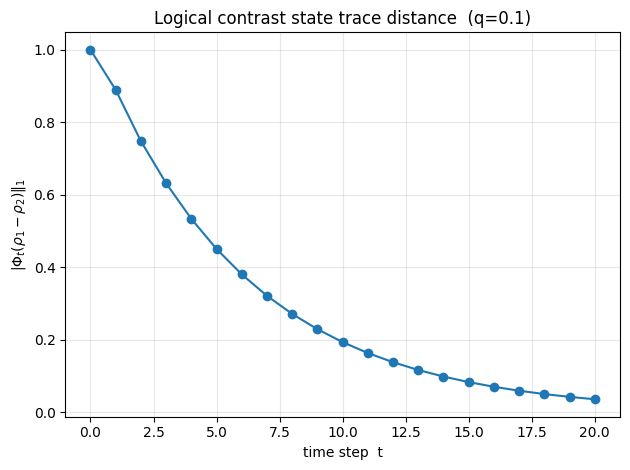

In [2]:
q = 0.1
Tmax = 20
channel = LogicalChannel(code, Tmax, q)

# contrast state rho1 - rho2  (traceless Hermitian)
rho = logical_basis_state(code, 0) - logical_basis_state(code, 1)
dim_L = 2 ** code.k


ts   = list(range(0, Tmax + 1))
dist = [trace_norm(channel(t, rho)) for t in ts]

plt.plot(ts, dist, marker='o')
plt.xlabel('time step  t')
plt.ylabel(r'$|\Phi_t(\rho_1-\rho_2)\|_1$')
plt.title(f'Logical contrast state trace distance  (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig(f"plots/Logical_contrast_state_trace_distance_q{q}.png")

plt.show()

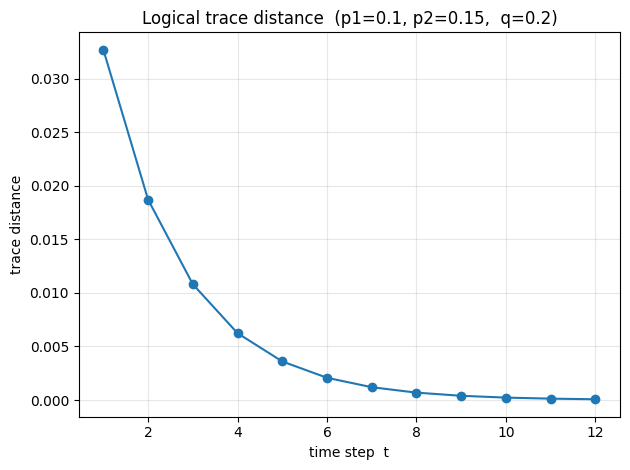

In [3]:
p1 = 0.1
p2 = 0.15
rho1 = input_state(code, p1)
rho2 = input_state(code, p2)
q    = 0.2
Tmax = 12
channel = LogicalChannel(code, Tmax, q)
ts   = list(range(1, Tmax + 1))

dist_vals = [trace_norm(channel(t, rho1 - rho2)) for t in ts]

plt.plot(ts, dist_vals, marker='o')
plt.xlabel('time step  t')
plt.ylabel(r'trace distance')
plt.title(f'Logical trace distance  (p1={p1}, p2={p2},  q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

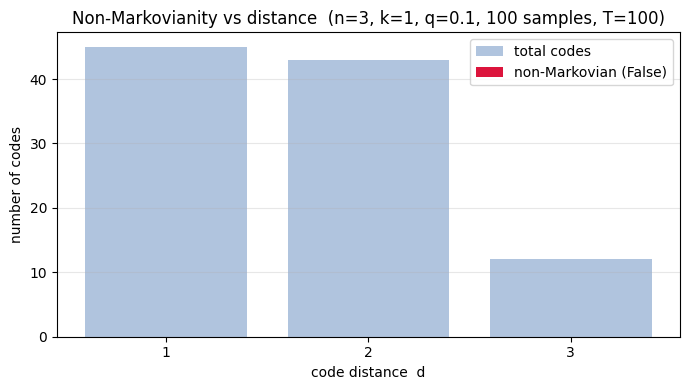

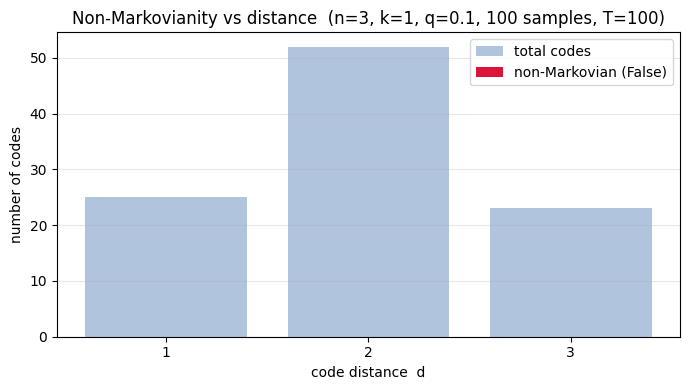

sample_H_brute: {1: {'total': 45, 'non_markovian': 0}, 2: {'total': 43, 'non_markovian': 0}, 3: {'total': 12, 'non_markovian': 0}}
sample_H      : {1: {'total': 25, 'non_markovian': 0}, 2: {'total': 52, 'non_markovian': 0}, 3: {'total': 23, 'non_markovian': 0}}


In [4]:
# ---- Monte Carlo: non-Markovianity of random codes, grouped by code distance ----
n, k, q   = 3, 1, 0.1
T_max = 100
n_samples = 100

res_brute = markovianity_vs_distance(sample_H_brute, n, k, q, n_samples=n_samples, T=T_max)
res_std   = markovianity_vs_distance(sample_H,       n, k, q, n_samples=n_samples, T=T_max)

print('sample_H_brute:', res_brute)
print('sample_H      :', res_std)

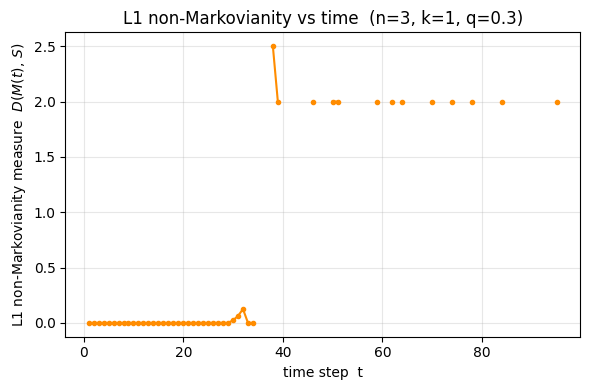

In [5]:
# ---- L1 stochastic-distance measure vs time (fixed q) ----
# Same one-step propagator  M(t) = A_t @ inv(A_{t-1})  as above, but scored with
# the L1 penalty distance: sum of |negative entries| + |column-sum deviations|.
# Markovian (column-stochastic propagator) => stays at 0.
from measures import l1_stochastic_distance

q    = 0.3
Tmax = 100
channel = LogicalChannel(code, Tmax, q)

A  = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts = list(range(1, Tmax + 1))

measure = []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure.append(np.nan)            # singular step: propagator undefined
    else:
        measure.append(l1_stochastic_distance(M))

plt.figure(figsize=(6, 4))
plt.plot(ts, measure, marker='o', ms=3, color='darkorange')
plt.xlabel('time step  t')
plt.ylabel(r'L1 non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'L1 non-Markovianity vs time  (n={code.n}, k={code.k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


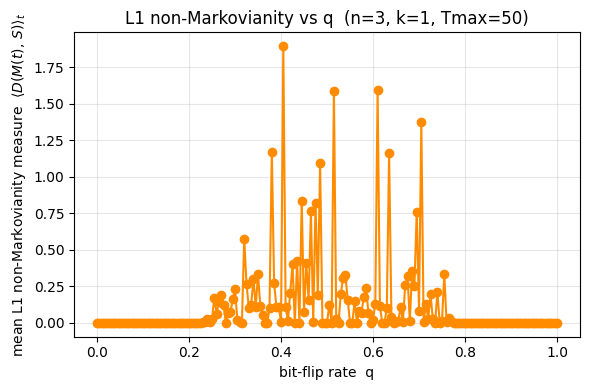

{np.float64(0.0): np.float64(0.0), np.float64(0.1): np.float64(0.0), np.float64(0.2): np.float64(0.028442), np.float64(0.3): np.float64(0.111265), np.float64(0.4): np.float64(0.075893), np.float64(0.5): np.float64(0.159275), np.float64(0.6): np.float64(0.005372), np.float64(0.7): np.float64(0.0), np.float64(0.8): np.float64(0.0), np.float64(0.9): np.float64(0.0), np.float64(1.0): np.float64(0.0)}


In [6]:
# ---- L1 stochastic-distance measure vs noise rate q (mean over time) ----
# For each q, average the per-step L1 penalty distance over t = 1..Tmax.
Tmax = 50
qs   = np.arange(0.0, 1.0 + 1e-9, 0.005)

mean_measure = []
for q in qs:
    channel = LogicalChannel(code, Tmax, q)
    A = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
    vals = []
    for t in range(1, Tmax + 1):
        try:
            M = A[t] @ np.linalg.inv(A[t - 1])
        except np.linalg.LinAlgError:
            vals.append(np.nan)
        else:
            vals.append(l1_stochastic_distance(M))
    mean_measure.append(np.nanmean(vals))

plt.figure(figsize=(6, 4))
plt.plot(qs, mean_measure, marker='o', color='darkorange')
plt.xlabel('bit-flip rate  q')
plt.ylabel(r'mean L1 non-Markovianity measure  $\langle D(M(t),\,S) \rangle_t $')
plt.title(f'L1 non-Markovianity vs q  (n={code.n}, k={code.k}, Tmax={Tmax})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(dict(zip(np.round(qs, 1), np.round(mean_measure, 6))))
